In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Task-1

np.uint8(100)

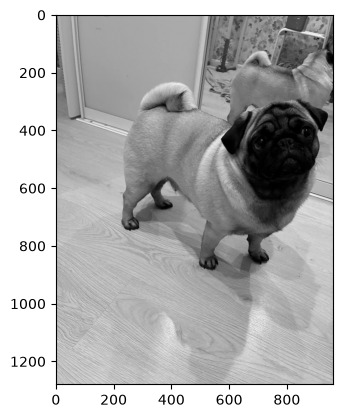

In [89]:
image = cv2.imread('photo_2026-02-01_18-11-53.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray') #массив не меняется, меняет только картинку
image.shape
image[0,0]

Task-2

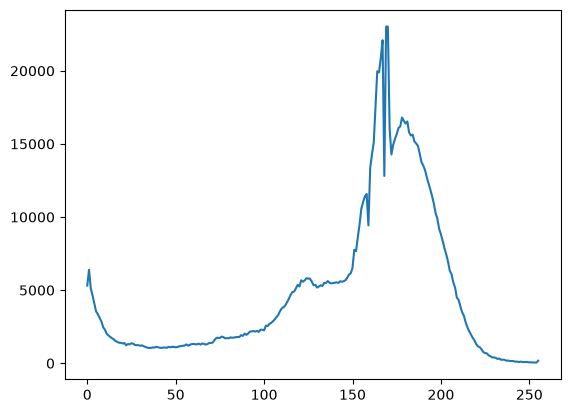

In [90]:
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate)

plt.plot(hist)

Task-3

Средняя яркость исходного : 150.07
Средняя яркость gamma=0.5 : 190.3
Средняя яркость gamma=2.0 : 98.55


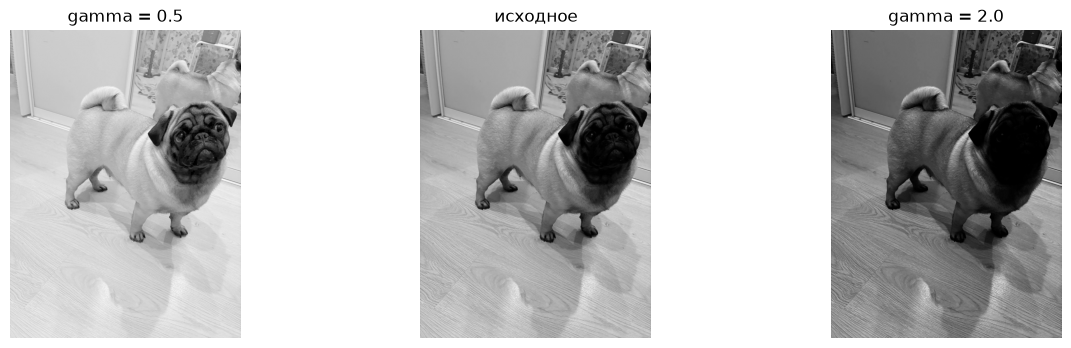

In [91]:
def gamma_correction(image_lc, gamma_lc):
    table = np.zeros(256, dtype=np.uint8)

    for r in range(256):
        new_value = ((r / 255) ** gamma_lc) * 255
        table[r] = round(new_value)

    return cv2.LUT(image, table)

bright = gamma_correction(image, 0.5)
dark   = gamma_correction(image, 2.0)
print('Средняя яркость исходного :', round(image.mean(), 2))
print('Средняя яркость gamma=0.5 :', round(bright.mean(), 2))
print('Средняя яркость gamma=2.0 :', round(dark.mean(), 2))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].set_title('gamma = 0.5')
ax[0].imshow(bright, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('исходное')
ax[1].imshow(image, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('gamma = 2.0')
ax[2].imshow(dark, cmap='gray', vmin=0, vmax=255)
for a in ax:
    a.axis('off')
plt.show()

Task-4

SSIM: 0.8770232919224512
MSE: 1763.298926595052


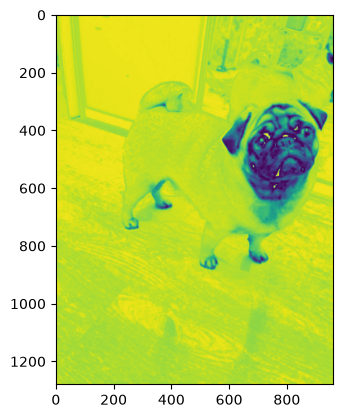

In [92]:
#gamma<1
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image, bright, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))
mse = mean_squared_error(image, bright)
print("MSE: {}".format(mse))
plt.imshow(diff)

SSIM: 0.8098102433717769
MSE: 1763.298926595052


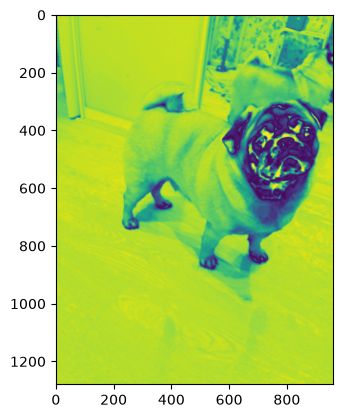

In [93]:
#gamma>1
(ssim, diff) = structural_similarity(image, dark, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))
mse = mean_squared_error(image, bright)
print("MSE: {}".format(mse))
plt.imshow(diff)

Task-5

150.07132080078125 51.137021149660484
128.05035237630207 74.27230971797381
132.6164013671875 61.827532459719386


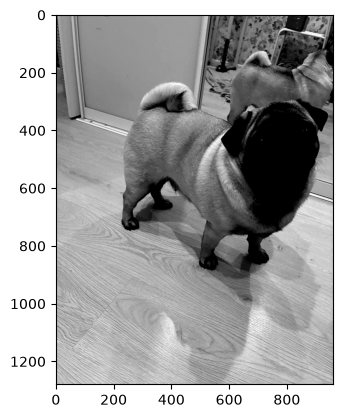

In [94]:

image5 = copy.deepcopy(image).astype(np.float32)

eq_gray = cv2.equalizeHist(image)
#разброс - контраст; чем выше число, тем ярче
mean1 = image.mean()
std1 = image.std()
mean2 = eq_gray.mean()
std2 = eq_gray.std()
print(mean1, std1)
print(mean2, std2)

height, width = image.shape
for y in range(height):
    for x in range(width):
        image5[y, x] = mean2 + (image5[y, x] - mean1) * (std2 / std1)

image5 = np.clip(image5, 0, 255)
image5 = image5.astype(np.uint8)

print(image5.mean(), image5.std())
plt.imshow(image5, cmap='gray')


Task-6

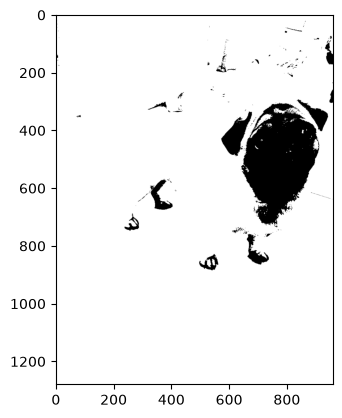

In [95]:
#50 BINARY
_,thresh1 = cv2.threshold(image,50,255,cv2.THRESH_BINARY)

plt.imshow(thresh1, cmap='gray')

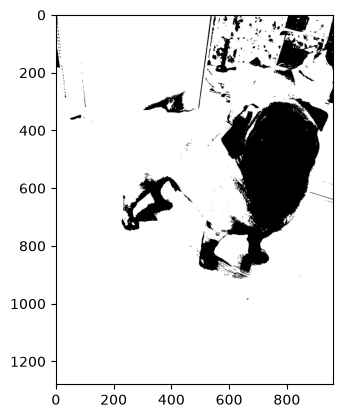

In [96]:
# 100 BINARY
_,thresh3 = cv2.threshold(image,100,255,cv2.THRESH_BINARY)

plt.imshow(thresh3, cmap='gray')

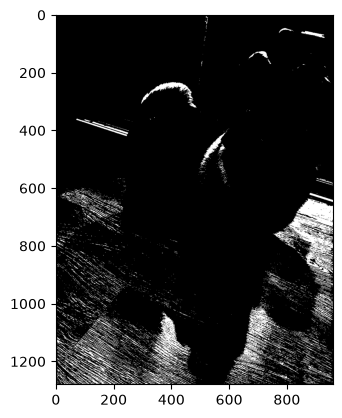

In [97]:
#200 BINARY
_,thresh1 = cv2.threshold(image,200,255,cv2.THRESH_BINARY)

plt.imshow(thresh1, cmap='gray')

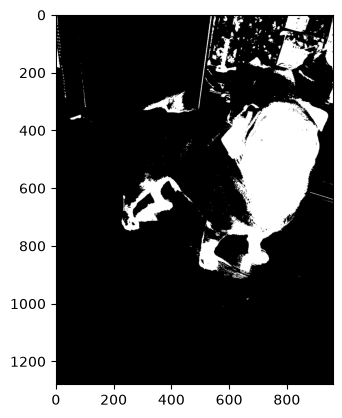

In [98]:
#100 BINARY_INV
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_BINARY_INV)

plt.imshow(thresh1, cmap='gray')

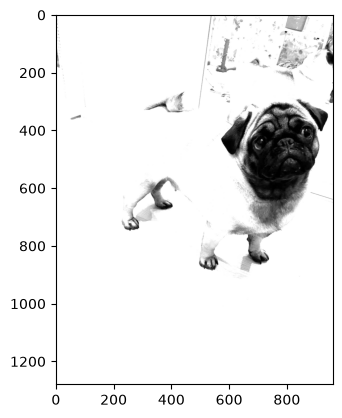

In [99]:
#100 TRUNC
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_TRUNC)

plt.imshow(thresh1, cmap='gray')

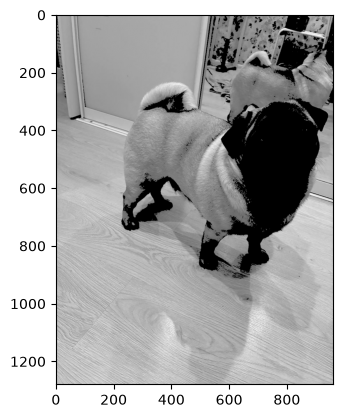

In [100]:
#100 TOZERO
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_TOZERO)

plt.imshow(thresh1, cmap='gray')

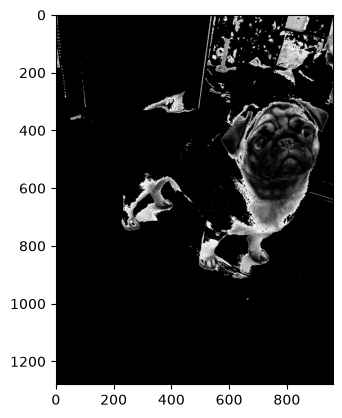

In [101]:
#100 TOZERO_INV
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_TOZERO_INV)

plt.imshow(thresh1, cmap='gray')